In [1]:
!pip -q install fastai datasets scikit-learn

In [2]:
import numpy as np
import pandas as pd
import random

from datasets import load_dataset
from sklearn.model_selection import train_test_split

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

In [3]:
ds = load_dataset("ag_news")

train_df = ds["train"].to_pandas()
test_df  = ds["test"].to_pandas()

train_df.head(), train_df["label"].value_counts()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

(                                                text  label
 0  Wall St. Bears Claw Back Into the Black (Reute...      2
 1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
 2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
 3  Iraq Halts Oil Exports from Main Southern Pipe...      2
 4  Oil prices soar to all-time record, posing new...      2,
 label
 2    30000
 3    30000
 1    30000
 0    30000
 Name: count, dtype: int64)

In [4]:
SAMPLE_N = 20000

train_df_sample = train_df.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)

train_df_sample["label"].value_counts()

,count
label,
1,5084
3,5003
0,4964
2,4949


In [5]:
train_df2, valid_df2 = train_test_split(
    train_df_sample,
    test_size=0.2,
    random_state=42,
    stratify=train_df_sample["label"]
)

train_df2 = train_df2.reset_index(drop=True)
valid_df2 = valid_df2.reset_index(drop=True)

print("Train:", len(train_df2), "Valid:", len(valid_df2), "Test:", len(test_df))

Train: 16000 Valid: 4000 Test: 7600


In [6]:
label_names = {0:"World", 1:"Sports", 2:"Business", 3:"Sci/Tech"}

train_df2["label_name"] = train_df2["label"].map(label_names)
valid_df2["label_name"] = valid_df2["label"].map(label_names)
test_df["label_name"]   = test_df["label"].map(label_names)

train_df2.head()

,text,label,label_name
0,Thai Queen Urges End to Violence in Muslim Sou...,0,World
1,Sharon Accepts Plan to Reduce Gaza Army Operat...,0,World
2,"Russia Mourns Hostage Deaths, Putin Criticized...",0,World
3,Mars Rovers #39; Mission Extends with New Goal...,3,Sci/Tech
4,Senate Panel Weighs In On Wireless Directory (...,3,Sci/Tech


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=50000,
        ngram_range=(1,2)
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        n_jobs=None
    ))
])

In [29]:
import time

start_traditional = time.time()

tfidf_lr.fit(train_df2["text"], train_df2["label"])

end_traditional = time.time()

traditional_time = end_traditional - start_traditional

print("Traditional model training time:", round(traditional_time,2), "seconds")

Traditional model training time: 13.68 seconds


In [10]:
valid_pred = tfidf_lr.predict(valid_df2["text"])
valid_acc = accuracy_score(valid_df2["label"], valid_pred)

print("TF-IDF + Logistic Regression (Valid) accuracy:", round(valid_acc, 4))
print("\nClassification report (Valid):")
print(classification_report(valid_df2["label"], valid_pred, target_names=[label_names[i] for i in range(4)]))

TF-IDF + Logistic Regression (Valid) accuracy: 0.9073

Classification report (Valid):
              precision    recall  f1-score   support

       World       0.91      0.90      0.90       993
      Sports       0.94      0.98      0.96      1017
    Business       0.88      0.88      0.88       990
    Sci/Tech       0.90      0.87      0.89      1000

    accuracy                           0.91      4000
   macro avg       0.91      0.91      0.91      4000
weighted avg       0.91      0.91      0.91      4000



In [16]:
cm_valid = confusion_matrix(valid_df2["label"], valid_pred)

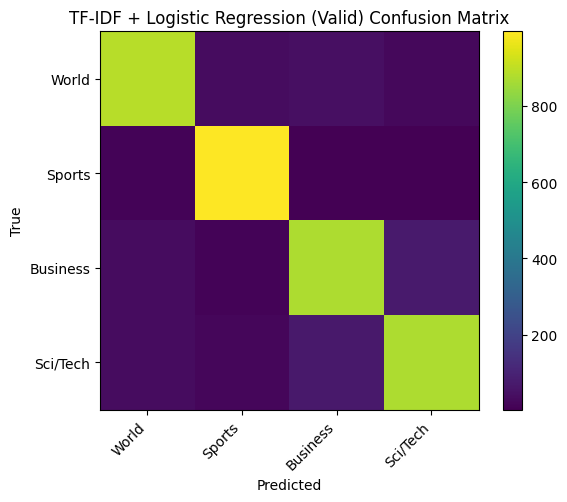

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cm_valid)
plt.xticks(range(4), [label_names[i] for i in range(4)], rotation=45, ha="right")
plt.yticks(range(4), [label_names[i] for i in range(4)])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("TF-IDF + Logistic Regression (Valid) Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

In [18]:
test_pred = tfidf_lr.predict(test_df["text"])
test_acc = accuracy_score(test_df["label"], test_pred)

print("TF-IDF + Logistic Regression (Test) accuracy:", round(test_acc, 4))

TF-IDF + Logistic Regression (Test) accuracy: 0.9016


In [19]:
from fastai.text.all import *
import time

# fastai works more reliably with string labels
train_df2 = train_df2.copy()
valid_df2 = valid_df2.copy()
test_df = test_df.copy()

train_df2["label_str"] = train_df2["label"].map(label_names)
valid_df2["label_str"] = valid_df2["label"].map(label_names)
test_df["label_str"]   = test_df["label"].map(label_names)

In [30]:
lm_df = pd.concat([train_df2[["text"]], valid_df2[["text"]]], axis=0).reset_index(drop=True)

# Language Model DataLoaders
dls_lm = TextDataLoaders.from_df(
    lm_df,
    text_col="text",
    is_lm=True,
    valid_pct=0.1,
    seed=42,
    bs=64
)

learn_lm = language_model_learner(
    dls_lm,
    AWD_LSTM,
    pretrained=True,
    drop_mult=0.5,
    metrics=[Perplexity()]
)

t0 = time.time()
start_lm = time.time()

learn_lm.fine_tune(1, 1e-2)

end_lm = time.time()

lm_time = end_lm - start_lm

print("Language model training time:", round(lm_time,2), "seconds")
print("LM fine-tune time (sec):", round(time.time() - t0, 2))

# Save the encoder for use with the classifier.
learn_lm.save_encoder("agnews_enc")


epoch,train_loss,valid_loss,perplexity,time
0,4.076005,3.731300,41.733341,01:06


epoch,train_loss,valid_loss,perplexity,time
0,3.481774,3.457640,31.741968,01:19


Language model training time: 146.27 seconds
LM fine-tune time (sec): 146.27


In [22]:
# Classifier DataLoaders
dls_clas = TextDataLoaders.from_df(
    train_df2,
    valid_df=valid_df2,
    text_col="text",
    label_col="label_str",
    text_vocab=dls_lm.vocab,
    bs=32,
    seed=42
)

learn_clas = text_classifier_learner(
    dls_clas,
    AWD_LSTM,
    pretrained=True,
    drop_mult=0.5,
    metrics=accuracy
)

# Encoder loaded with LM
learn_clas.load_encoder("agnews_enc")

In [31]:
t1 = time.time()
start_clf = time.time()

learn_clas.fine_tune(3, 2e-2)

end_clf = time.time()

classifier_time = end_clf - start_clf

print("Classifier training time:", round(classifier_time,2), "seconds")
print("Classifier fine-tune time (sec):", round(time.time() - t1, 2))

epoch,train_loss,valid_loss,accuracy,time
0,0.177218,0.297135,0.915937,00:28


epoch,train_loss,valid_loss,accuracy,time
0,0.231191,0.306484,0.898125,00:49
1,0.160352,0.271300,0.916562,00:49
2,0.084440,0.286524,0.917500,00:49


Classifier training time: 177.39 seconds
Classifier fine-tune time (sec): 177.39


In [24]:
learn_clas.validate()

[0.2548058331012726, 0.9184374809265137]

In [26]:
# Build test dataloader
test_dl = learn_clas.dls.test_dl(test_df["text"])

preds, _ = learn_clas.get_preds(dl=test_dl)
pred_idx = preds.argmax(dim=1).cpu().numpy()

# label vocab
label_vocab = learn_clas.dls.vocab[1]

# Convert the predicted idx to label name
pred_labels = [label_vocab[i] for i in pred_idx]

# Calculate test accuracy
ulmfit_test_acc = (np.array(pred_labels) == test_df["label_str"].values).mean()
print("ULMFiT (Test) accuracy:", round(float(ulmfit_test_acc), 4))

ULMFiT (Test) accuracy: 0.9153


In [27]:
from sklearn.metrics import confusion_matrix, classification_report

cm_ulmfit = confusion_matrix(test_df["label_str"], pred_labels, labels=list(label_names.values()))
print(cm_ulmfit)

print("\nClassification report (Test):")
print(classification_report(test_df["label_str"], pred_labels))

[[1746   42   68   44]
 [  19 1862   16    3]
 [  71   17 1634  178]
 [  59   11  116 1714]]

Classification report (Test):
              precision    recall  f1-score   support

    Business       0.89      0.86      0.88      1900
    Sci/Tech       0.88      0.90      0.89      1900
      Sports       0.96      0.98      0.97      1900
       World       0.92      0.92      0.92      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



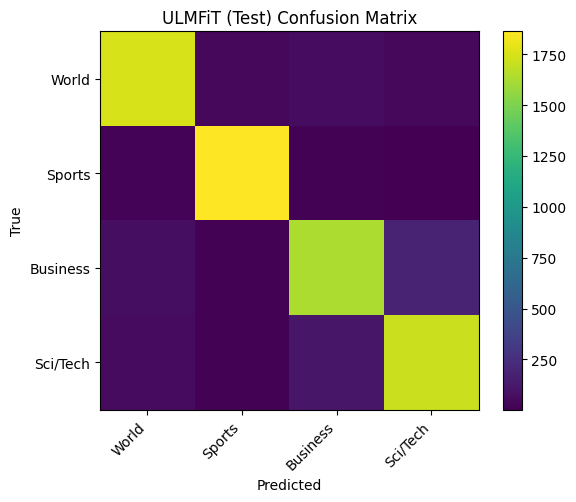

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cm_ulmfit)
plt.xticks(range(4), list(label_names.values()), rotation=45, ha="right")
plt.yticks(range(4), list(label_names.values()))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ULMFiT (Test) Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

In [32]:
print("\n===== Training Time Comparison =====")

print("Traditional NLP model:", round(traditional_time,2), "seconds")

print("ULMFiT Language Model:", round(lm_time,2), "seconds")

print("ULMFiT Classifier:", round(classifier_time,2), "seconds")

print("Total ULMFiT training time:", round(lm_time + classifier_time,2), "seconds")


===== Training Time Comparison =====
Traditional NLP model: 13.68 seconds
ULMFiT Language Model: 146.27 seconds
ULMFiT Classifier: 177.39 seconds
Total ULMFiT training time: 323.67 seconds
